In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("/content/medical_insurance.csv")

In [6]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [10]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Feature Engineering

<Axes: xlabel='age', ylabel='charges'>

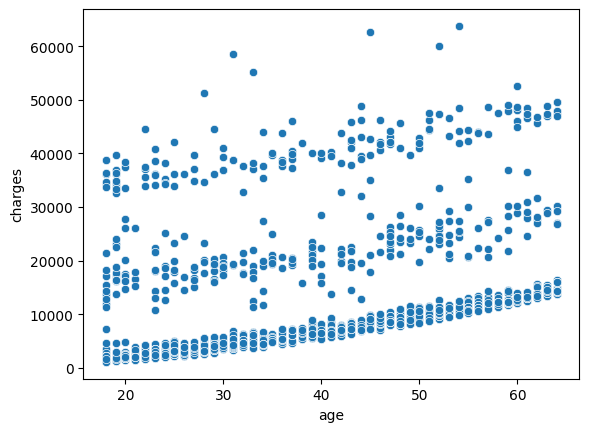

In [11]:
sns.scatterplot(x="age",y="charges",data=df)#non linear graph

In [12]:
from scipy.stats import pearsonr

In [13]:
v1=pearsonr(df["age"],df["charges"])

In [14]:
v1

PearsonRResult(statistic=np.float64(0.29862366562936266), pvalue=np.float64(3.3160729998345e-58))

In [15]:
from scipy.stats import spearmanr

In [16]:
v2=spearmanr(df["age"],df["charges"])

In [17]:
v2

SignificanceResult(statistic=np.float64(0.5358797599935969), pvalue=np.float64(6.905661241953329e-206))

In [18]:
df["age_sq"]=df["age"]**2

<Axes: xlabel='age_sq', ylabel='charges'>

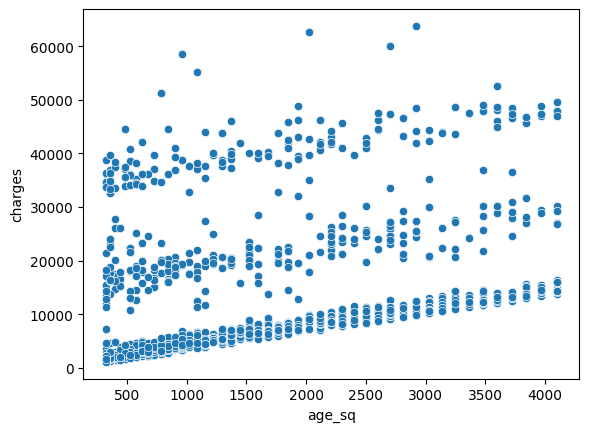

In [19]:
sns.scatterplot(x="age_sq",y="charges",data=df)

/tmp/ipykernel_21445/3454039009.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["charges"])


<Axes: xlabel='charges', ylabel='Density'>

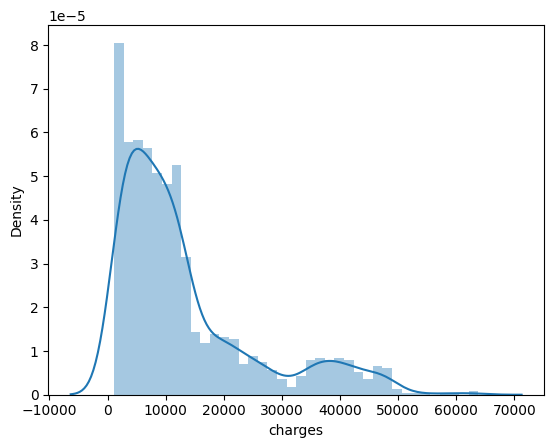

In [20]:
sns.distplot(df["charges"])

In [21]:
df["charges_log"]=np.log(df["charges"])

/tmp/ipykernel_21445/1907057310.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["charges_log"])


<Axes: xlabel='charges_log', ylabel='Density'>

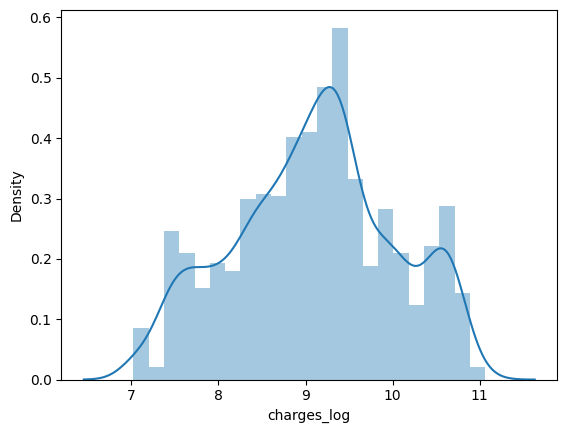

In [22]:
sns.distplot(df["charges_log"])

quatratic curve

<Axes: xlabel='age_sq', ylabel='charges_log'>

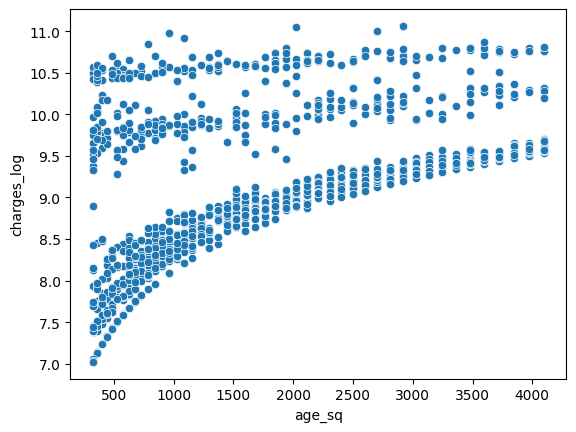

In [23]:
sns.scatterplot(x="age_sq",y="charges_log",data=df)#quadratic cuve

In [24]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'age_sq', 'charges_log'],
      dtype='object')

<Axes: xlabel='sex', ylabel='charges'>

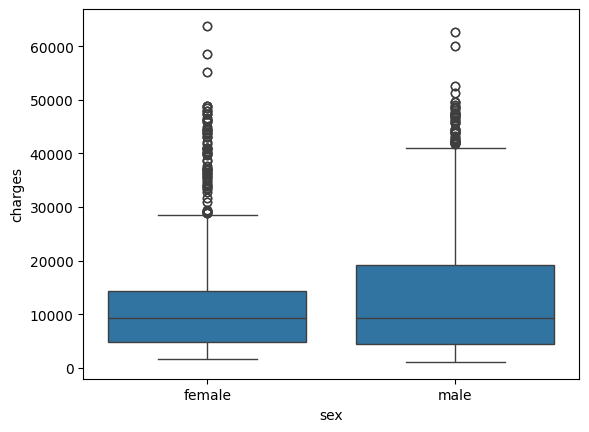

In [25]:
sns.boxplot(x="sex",y="charges",data=df)
#

In [26]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'age_sq', 'charges_log'],
      dtype='object')

In [27]:
def BMI_Category(x):
  if x<18.5:
    return "under_weight"
  elif x>18.5 and x<=25:
    return "normal"
  elif x>25 and x<=30:
    return "over weight"
  else:
    return "Obese"

In [28]:
df["bmi_cat"]=df["bmi"].apply(BMI_Category)

<Axes: xlabel='bmi_cat', ylabel='charges'>

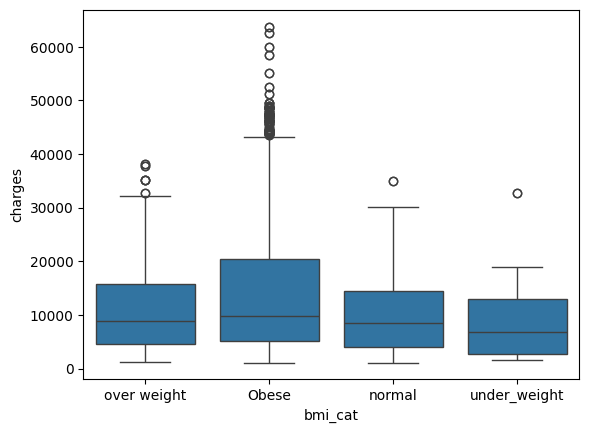

In [29]:
sns.boxplot(x="bmi_cat",y="charges",data=df)
#

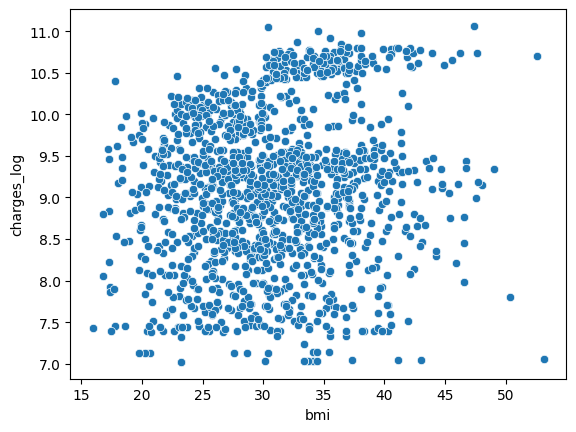

In [30]:
sns.scatterplot(x="bmi",y="charges_log",data=df)
plt.show()
#

In [31]:
df["bmi_sq"]=df["bmi"]**2

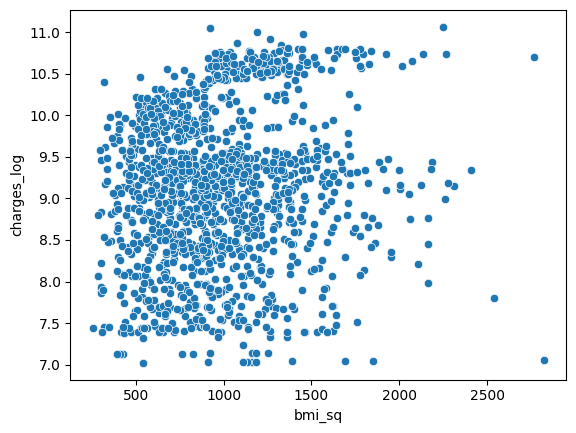

In [32]:
sns.scatterplot(x="bmi_sq",y="charges_log",data=df)
plt.show()
#

In [33]:
df["age&bmi"]=df["age"]*df["bmi"]
#

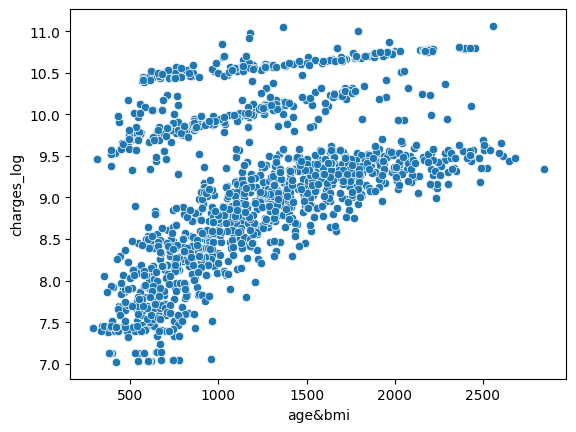

In [34]:
sns.scatterplot(x="age&bmi",y="charges_log",data=df)
plt.show()
#quadratic relationship

In [35]:
df

,age,sex,bmi,children,smoker,region,charges,age_sq,charges_log,bmi_cat,bmi_sq,age&bmi
0,19,female,27.900,0,yes,southwest,16884.92400,361,9.734176,over weight,778.410000,530.100
1,18,male,33.770,1,no,southeast,1725.55230,324,7.453302,Obese,1140.412900,607.860
2,28,male,33.000,3,no,southeast,4449.46200,784,8.400538,Obese,1089.000000,924.000
3,33,male,22.705,0,no,northwest,21984.47061,1089,9.998092,normal,515.517025,749.265
4,32,male,28.880,0,no,northwest,3866.85520,1024,8.260197,over weight,834.054400,924.160
...,...,...,...,...,...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180,2209,9.056007,Obese,2053.902400,2130.040
2768,21,female,34.600,0,no,southwest,2020.17700,441,7.610940,Obese,1197.160000,726.600
2769,19,male,26.030,1,yes,northwest,16450.89470,361,9.708135,over weight,677.560900,494.570
2770,23,male,18.715,0,no,northwest,21595.38229,529,9.980235,normal,350.251225,430.445


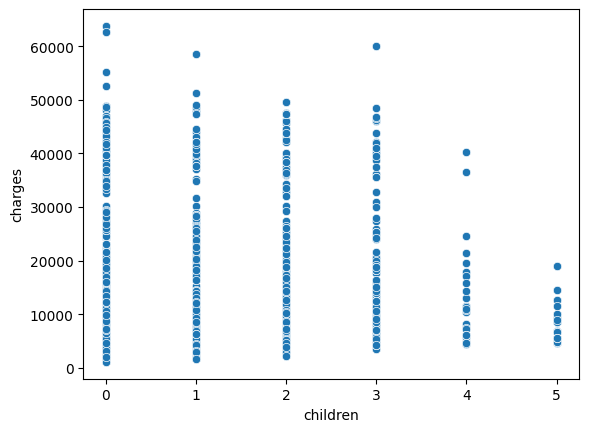

In [36]:
sns.scatterplot(x="children",y="charges",data=df)
plt.show()
#

In [37]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'age_sq', 'charges_log', 'bmi_cat', 'bmi_sq', 'age&bmi'],
      dtype='object')

In [38]:
df["children"]=df["children"]

In [39]:
df["children"].unique()

array([0, 1, 3, 2, 5, 4])

In [40]:
def family(x):
  if x<=3:
    return "small_family"
  else:
    return "large_family"

In [41]:
df["family"]=df["children"].apply(family)

In [42]:
df["family"].value_counts()

,count
family,
small_family,2678
large_family,94


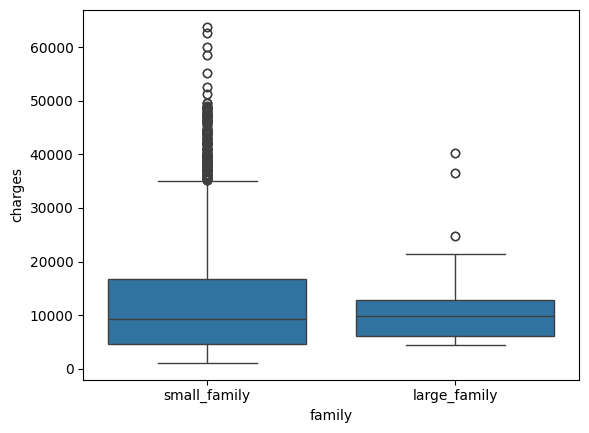

In [43]:
sns.boxplot(x="family",y="charges",data=df)
plt.show()
#
#

In [44]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'age_sq', 'charges_log', 'bmi_cat', 'bmi_sq', 'age&bmi', 'family'],
      dtype='object')

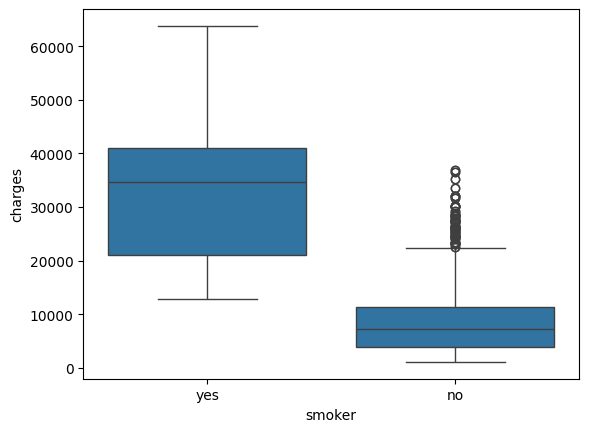

In [45]:
sns.boxplot(x="smoker",y="charges",data=df)
plt.show()
#

In [46]:
df1=pd.read_csv("/content/medical_insurance.csv")

In [47]:
df1

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


In [48]:
df1.drop(columns=["region"],inplace=True)

In [49]:
def convert_cat(x):
  if x=="male":
    return 1
  else:
    return 0

In [50]:
df1["sex"]=df1["sex"].apply(convert_cat)

In [51]:
def smoker(x):
  if x=="yes":
    return 1
  else:
    return 0

In [52]:
df1["smoker"]=df1["smoker"].apply(smoker)

In [53]:
x=df1.drop(columns=["charges"])

In [54]:
y=df1["charges"]

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=365)

In [57]:
from sklearn.preprocessing import PolynomialFeatures

In [58]:
poly=PolynomialFeatures(degree=2,include_bias=False)

In [59]:
xtrain_poly=poly.fit_transform(xtrain)

In [60]:
xtest_poly=poly.transform(xtest)

In [61]:
xtrain.shape

(2217, 5)

In [62]:
xtrain_poly.shape

(2217, 20)

In [63]:
from sklearn.linear_model import LinearRegression

In [64]:
model=LinearRegression()

In [65]:
from sklearn.preprocessing import StandardScaler

In [66]:
ss=StandardScaler()

In [67]:
xtrain_poly_scaled=ss.fit_transform(xtrain_poly)

In [68]:
xtest_poly_scaled=ss.transform(xtest_poly)

In [69]:
model.fit(xtrain_poly_scaled,ytrain)

LinearRegression()

In [70]:
model.score(xtrain_poly_scaled,ytrain)

0.8415527714447517

In [71]:
model.score(xtest_poly_scaled,ytest)
#

0.8479789547265635

In [72]:
from sklearn.metrics import mean_squared_error

y_train_pred = model.predict(xtrain_poly_scaled)
y_test_pred = model.predict(xtest_poly_scaled)

mse_train = mean_squared_error(ytrain, y_train_pred)
mse_test = mean_squared_error(ytest, y_test_pred)

print(f"Mean Squared Error on training data: {mse_train}")
print(f"Mean Squared Error on test data: {mse_test}")

Mean Squared Error on training data: 22760569.248174593
Mean Squared Error on test data: 24779682.818789866


In [73]:
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

print(f"Root Mean Squared Error on training data: {rmse_train}")
print(f"Root Mean Squared Error on test data: {rmse_test}")

Root Mean Squared Error on training data: 4770.80383668985
Root Mean Squared Error on test data: 4977.919527150862


In [74]:
from sklearn.metrics import r2_score

r2_train = r2_score(ytrain, y_train_pred)
r2_test = r2_score(ytest, y_test_pred)

print(f"R-squared score on training data: {r2_train}")
print(f"R-squared score on test data: {r2_test}")

R-squared score on training data: 0.8415527714447517
R-squared score on test data: 0.8479789547265635


Sample of Actual vs. Predicted Charges:
      Actual Charges  Predicted Charges
467      12643.37780       14451.111768
881       2789.05740        4724.045573
2239     11729.67950       12587.164538
2366     25517.11363       12383.503793
1692     20177.67113        6987.412047


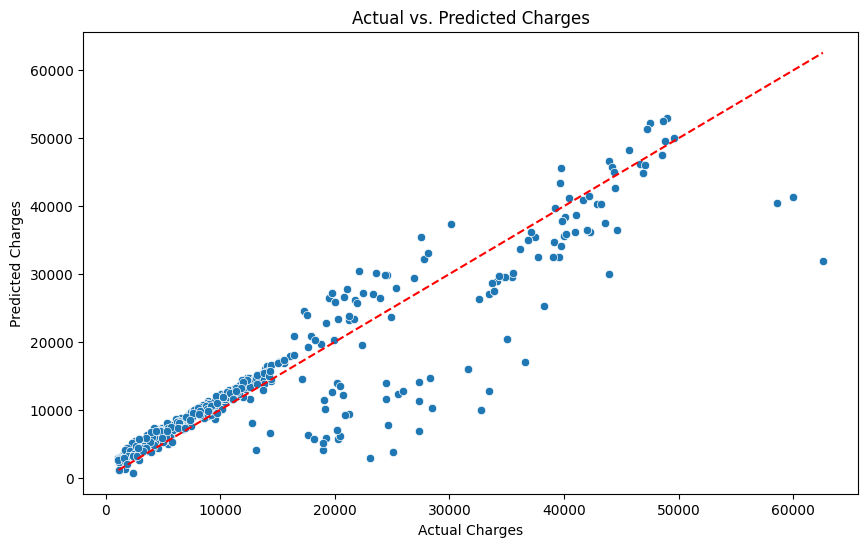

In [75]:
import pandas as pd

# Make predictions on the scaled test data
y_pred = model.predict(xtest_poly_scaled)

# Display some actual vs. predicted values
predictions_df = pd.DataFrame({'Actual Charges': ytest, 'Predicted Charges': y_pred})
print("Sample of Actual vs. Predicted Charges:")
print(predictions_df.head())

# You can also visualize the predictions if you like
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=ytest, y=y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs. Predicted Charges")
plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], 'r--') # Reference line
plt.show()



### Function to predict charges for new inputs

In [76]:
def predict_charges(age, sex, bmi, children, smoker):
    # Create a DataFrame from the input, ensuring column order matches training data
    new_data = pd.DataFrame([{
        'age': age,
        'sex': sex,
        'bmi': bmi,
        'children': children,
        'smoker': smoker
    }])

    # Apply polynomial features
    new_data_poly = poly.transform(new_data)

    # Scale the features
    new_data_scaled = ss.transform(new_data_poly)

    # Make prediction
    predicted_charge = model.predict(new_data_scaled)[0]

    return predicted_charge

print("Function 'predict_charges' created successfully.")

Function 'predict_charges' created successfully.


### Example of using the prediction function

In [79]:
age = int(input("Enter age: "))
sex = int(input("Enter sex (0 for female, 1 for male): "))
bmi = float(input("Enter BMI: "))
children = int(input("Enter number of children: "))
smoker = int(input("Enter smoker status (0 for no, 1 for yes): "))

predicted_value = predict_charges(age=age, sex=sex, bmi=bmi, children=children, smoker=smoker)
print(f"Predicted charges for the given input: ₹{predicted_value:.2f}")

Enter age: 25
Enter sex (0 for female, 1 for male): 1
Enter BMI: 12.5
Enter number of children: 1
Enter smoker status (0 for no, 1 for yes): 0
Predicted charges for the given input: ₹2188.54
